# Threshold-Based Pairs Trading — Baseline Model
### GSoM Hackathon · Statistical Arbitrage EWS · Zenti Dataset (Weekly, Jan 2000 – Apr 2021)

**Strategy:** Z-score threshold on cointegrated spreads (±2σ entry, 0 exit, 1-week delay)  
**Split:** Train Jan 2000 – Dec 2019 · Test Jan 2020 – Apr 2021 (incl. COVID)  
**Purpose:** Baseline for comparison with the LSTM anomaly detection model

---

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import timedelta

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.35

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH = '/Users/nico/Desktop/GSOM/New Tech/Project/Zenti Exercises May 2024.xlsx'
PKL_PATH  = '/Users/nico/Desktop/GSOM/New Tech/Project/total_pairs_zenti.pkl'

# ── Temporal split ───────────────────────────────────────────────────────────
TRAIN_END  = '2019-12-31'   # train: inizio dati → 2019
TEST_START = '2020-01-01'   # test : 2020 → fine dati (incl. COVID)

N_YEARS_TRAIN = 20
N_YEARS_TEST  = 1.33

# ── Strategy parameters ───────────────────────────────────────────────────────
ENTRY_LEVEL = 2    # z-score entry threshold (|z| > ENTRY_LEVEL → enter)
EXIT_LEVEL  = 0    # z-score exit threshold  (|z| < EXIT_LEVEL  → exit)
STABILIZING = 5    # bars to skip at start of each period

## 2. Data Loading

In [3]:
df_raw    = pd.read_excel(DATA_PATH, sheet_name='Markets',  index_col=0, parse_dates=True)
df_meta   = pd.read_excel(DATA_PATH, sheet_name='Metadata')

df_prices = df_raw.drop(columns=['Y'])
y_labels  = df_raw['Y']

type_map      = dict(zip(df_meta['Variable name'].str.strip(), df_meta['Type']))
feature_types = {col: type_map.get(col, 'Unknown') for col in df_prices.columns}

with open(PKL_PATH, 'rb') as f:
    total_pairs = pickle.load(f)

print(f'Dataset  : {df_prices.shape[0]} obs × {df_prices.shape[1]} features')
print(f'Range    : {df_prices.index[0].date()} → {df_prices.index[-1].date()}')
print(f'Pairs    : {len(total_pairs)}')
print()
for feat1, feat2, p in total_pairs:
    print(f'  {feat1:12s} / {feat2:12s}  β={p["coint_coef"]:.3f}  HL={p["half_life"]}wk  H={p["hurst_exponent"]:.3f}')

Dataset  : 1111 obs × 42 features
Range    : 2000-01-11 → 2021-04-20
Pairs    : 4

  LG30TRUU     / LP01TREU      β=3.343  HL=82wk  H=0.508
  LP01TREU     / MXEU          β=0.101  HL=64wk  H=0.549
  EMUSTRUU     / LMBITR        β=0.775  HL=25wk  H=0.505
  LMBITR       / LUACTRUU      β=0.348  HL=32wk  H=0.535


## 3. Functions

All functions are adapted from `Threshold-Based Trading Model .ipynb` with the following changes for **weekly** data:
- `add_trading_duration`: counts weeks (not intraday bars) by comparing index timestamps
- `calculate_balance`: short rental cost = **1% / 52** per week (not 1% / 252 per day)
- `calculate_sharpe_ratio`: annualises via **√52** on weekly returns (not daily resampling)
- `calculate_maximum_drawdown`: duration reported in weeks
- `calculate_portfolio_sharpe_ratio`: no daily resampling; uses weekly returns directly

In [4]:
def shade_risk_off(ax, y_labels, alpha=0.15, color='red'):
    """Shade contiguous Y=1 (risk-off) periods on ax."""
    in_ro, start = False, None
    for date, val in y_labels.items():
        if val == 1 and not in_ro:
            start, in_ro = date, True
        elif val == 0 and in_ro:
            ax.axvspan(start, date, alpha=alpha, color=color, label='_nolegend_')
            in_ro = False
    if in_ro:
        ax.axvspan(start, y_labels.index[-1], alpha=alpha, color=color, label='_nolegend_')


def add_trading_duration(data):
    """
    Counts how many weekly bars each position is held.
    Adapted from the original (daily) version: index comparison instead of index.day.
    """
    data['trading_duration'] = [0] * len(data)
    previous_unit = 0.
    new_position_counter = 0
    prev_index = data.index[0]

    for index, row in data.iterrows():
        if previous_unit == row['numUnits']:
            if previous_unit != 0.:
                if index != prev_index:
                    new_position_counter += 1
                    prev_index = index
                if index == data.index[-1]:
                    data.loc[index, 'trading_duration'] = new_position_counter
            continue
        else:
            if previous_unit == 0.:
                previous_unit = row['numUnits']
                new_position_counter = 1
                prev_index = index
                continue
            else:
                data.loc[index, 'trading_duration'] = new_position_counter
                previous_unit = row['numUnits']
                new_position_counter = 1
                prev_index = index
                continue

    return data['trading_duration']

In [5]:
def return_per_position(row, beta=None):
    if row['end_position'] != 0:
        y_returns = (row['y'] - row['y_entry']) / row['y_entry']
        x_returns = (row['x'] - row['x_entry']) / row['x_entry']
        if beta > 1.:
            return ((1 / beta) * y_returns - 1 * x_returns) * row['positions']
        else:
            return (y_returns - beta * x_returns) * row['positions']
    else:
        return 0


def calculate_position_returns(y, x, beta, positions):
    y = y.copy(); y.name = 'y'
    x = x.copy(); x.name = 'x'

    new_positions = positions.diff()[positions.diff() != 0].index.values
    end_position  = pd.Series(data=[0] * len(y), index=y.index, name='end_position')
    end_position[new_positions] = 1.
    if positions.iloc[-1] != 0:
        end_position.iloc[-1] = 1.

    y_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='y_entry')
    x_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='x_entry')
    y_entry[new_positions] = y[new_positions]
    x_entry[new_positions] = x[new_positions]
    y_entry = y_entry.shift().ffill()
    x_entry = x_entry.shift().ffill()

    positions.name = 'positions'
    df = pd.concat([y, x, positions.shift().fillna(0), y_entry, x_entry, end_position], axis=1)
    returns     = df.apply(lambda row: return_per_position(row, beta), axis=1).fillna(0)
    cum_returns = np.cumprod(returns + 1) - 1
    df['ret']   = returns
    returns.name = 'position_return'

    return returns, cum_returns, df

In [6]:
def calculate_balance(y, x, beta, positions, trading_durations):
    """
    Full balance simulation with transaction costs.
    Weekly adaptation: short rental cost = 1% / 52 per week (not / 252 per day).
    """
    y_returns = y.pct_change().fillna(0) * positions
    x_returns = -x.pct_change().fillna(0) * positions

    leg_y = [np.nan] * len(y)
    leg_x = [np.nan] * len(y)
    pnl_y = [np.nan] * len(y)
    pnl_x = [np.nan] * len(y)
    account_balance = [np.nan] * len(y)

    new_positions_idx  = positions.diff()[positions.diff() != 0].index.values
    end_positions_idx  = trading_durations[trading_durations != 0].index.values
    position_trigger   = pd.Series([0] * len(y), index=y.index, name='position_trigger')
    position_trigger[new_positions_idx] = 2.
    position_trigger[end_positions_idx] = position_trigger[end_positions_idx] - 1.
    position_trigger   = position_trigger * positions.abs()

    position_investment = 1.0  # will be updated at each new position open

    for i in range(len(y)):
        if i == 0:
            pnl_y[0] = 0; pnl_x[0] = 0; account_balance[0] = 1
            leg_y[0] = 1 / beta if beta > 1 else 1
            leg_x[0] = 1         if beta > 1 else beta
            continue

        if positions.iloc[i] == 0:
            pnl_y[i] = 0; pnl_x[i] = 0
            leg_y[i] = leg_y[i-1]; leg_x[i] = leg_x[i-1]
            account_balance[i] = account_balance[i-1]

        elif position_trigger.iloc[i] in (1, 2):  # new position (1 = open+close same bar)
            position_investment = account_balance[i-1]
            if beta > 1:
                pnl_y[i] = y_returns.iloc[i] * position_investment * (1 / beta)
                pnl_x[i] = x_returns.iloc[i] * position_investment
            else:
                pnl_y[i] = y_returns.iloc[i] * position_investment
                pnl_x[i] = x_returns.iloc[i] * position_investment * beta

            # update legs
            if beta > 1:
                if positions.iloc[i] == 1:
                    leg_y[i] = position_investment * (1/beta) + pnl_y[i]
                    leg_x[i] = position_investment - pnl_x[i]
                else:
                    leg_y[i] = position_investment * (1/beta) - pnl_y[i]
                    leg_x[i] = position_investment + pnl_x[i]
            else:
                if positions.iloc[i] == 1:
                    leg_y[i] = position_investment + pnl_y[i]
                    leg_x[i] = position_investment * beta - pnl_x[i]
                else:
                    leg_y[i] = position_investment - pnl_y[i]
                    leg_x[i] = position_investment * beta + pnl_x[i]

            # commission + bid-ask (0.28% per leg, one-off at open)
            if beta >= 1:
                pnl_y[i] -= 0.0028 * (1/beta) * position_investment
                pnl_x[i] -= 0.0028 * position_investment
            else:
                pnl_y[i] -= 0.0028 * position_investment
                pnl_x[i] -= 0.0028 * beta * position_investment

            # short rental for 1-bar positions (trigger == 1 only)
            if position_trigger.iloc[i] == 1:
                if positions.iloc[i] == 1:
                    if beta >= 1:
                        pnl_x[i] -= (0.01 / 52) * position_investment
                    else:
                        pnl_x[i] -= (0.01 / 52) * beta * position_investment
                else:
                    if beta >= 1:
                        pnl_y[i] -= (0.01 / 52) * (1/beta) * position_investment
                    else:
                        pnl_y[i] -= (0.01 / 52) * position_investment

            account_balance[i] = account_balance[i-1] + pnl_y[i] + pnl_x[i]

        else:  # ongoing position
            pnl_y[i] = y_returns.iloc[i] * leg_y[i-1]
            pnl_x[i] = x_returns.iloc[i] * leg_x[i-1]

            if positions.iloc[i] == 1:
                leg_y[i] = leg_y[i-1] + pnl_y[i]
                leg_x[i] = leg_x[i-1] - pnl_x[i]
            else:
                leg_y[i] = leg_y[i-1] - pnl_y[i]
                leg_x[i] = leg_x[i-1] + pnl_x[i]

            # short rental at position close (weekly: /52)
            if position_trigger.iloc[i] == -1:
                dur = trading_durations.iloc[i]
                if positions.iloc[i] == 1:
                    if beta >= 1:
                        pnl_x[i] -= dur * (0.01 / 52) * position_investment
                    else:
                        pnl_x[i] -= dur * (0.01 / 52) * beta * position_investment
                else:
                    if beta >= 1:
                        pnl_y[i] -= dur * (0.01 / 52) * (1/beta) * position_investment
                    else:
                        pnl_y[i] -= dur * (0.01 / 52) * position_investment

            account_balance[i] = account_balance[i-1] + pnl_y[i] + pnl_x[i]

    pnl = [pnl_y[i] + pnl_x[i] for i in range(len(y))]
    balance         = pd.Series(account_balance, index=y.index, name='account_balance')
    returns         = balance.pct_change().fillna(0);  returns.name = 'returns'
    pnl             = pd.Series(pnl,        index=y.index, name='pnl')
    pnl_y_s         = pd.Series(pnl_y,      index=y.index, name='pnl_y')
    pnl_x_s         = pd.Series(pnl_x,      index=y.index, name='pnl_x')
    leg_y_s         = pd.Series(leg_y,       index=y.index, name='leg_y')
    leg_x_s         = pd.Series(leg_x,       index=y.index, name='leg_x')

    return pd.concat([balance, pnl, pnl_y_s, pnl_x_s, leg_y_s, leg_x_s,
                      returns, position_trigger, positions, y, x,
                      trading_durations], axis=1)

In [7]:
def apply_costs(row, fixed_costs_per_trade, short_costs_per_period, beta=0):
    if beta == 0:
        beta = row['beta_position']
    if row['position_during_day'] == 1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade * (1/beta) + fixed_costs_per_trade + short_costs_per_period * row['trading_duration']
        else:
            return fixed_costs_per_trade * beta + fixed_costs_per_trade + short_costs_per_period * row['trading_duration'] * beta
    elif row['position_during_day'] == -1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade * (1/beta) + fixed_costs_per_trade + short_costs_per_period * row['trading_duration'] * (1/beta)
        else:
            return fixed_costs_per_trade * beta + fixed_costs_per_trade + short_costs_per_period * row['trading_duration']
    else:
        return 0


def add_transaction_costs(summary, beta=0, commission_costs=0.08, market_impact=0.2, short_rental=1):
    fixed_costs_per_trade   = (commission_costs + market_impact) / 100
    short_costs_per_period  = (short_rental / 52) / 100  # weekly: /52 not /252
    costs = summary.apply(lambda row: apply_costs(row, fixed_costs_per_trade, short_costs_per_period, beta), axis=1)
    return summary['position_return'] - costs


def trade_summary(series, beta=0):
    for attribute, attribute_name in series:
        try:
            attribute.name = attribute_name
        except Exception:
            continue
    summary = pd.concat([item[0] for item in series], axis=1)
    summary['numUnits'] = summary['numUnits'].shift().fillna(0)
    summary = summary.rename(columns={'numUnits': 'position_during_day'})
    summary['position_ret_with_costs'] = add_transaction_costs(summary, beta)
    return summary

In [8]:
def calculate_sharpe_ratio(ret):
    """
    Annualised Sharpe ratio on in-position weeks only (ret != 0), rf = 0.
    Standard for strategy-vs-strategy comparison (academic / competition context).
    Formula: (mean_weekly_active / std_weekly_active) * sqrt(52)
    """
    active = ret[ret != 0]
    if len(active) == 0 or active.std() == 0:
        return 0.
    return (active.mean() / active.std()) * np.sqrt(52)


def calculate_metrics(cum_returns, n_years):
    avg_total_roi  = np.mean(cum_returns)
    avg_annual_roi = ((1 + avg_total_roi / 100) ** (1 / float(n_years)) - 1) * 100
    print(f'Average total ROI  : {avg_total_roi:.2f}%')
    print(f'Average annual ROI : {avg_annual_roi:.2f}%')
    arr = np.asarray(cum_returns)
    positive_pct = len(arr[arr > 0]) * 100 / max(len(arr), 1)
    print(f'Pairs with positive returns: {positive_pct:.1f}%')
    return avg_total_roi, avg_annual_roi, positive_pct

In [9]:
def calculate_portfolio_sharpe_ratio(performance, pairs):
    """
    Equal-weighted portfolio Sharpe ratio, rf = 0, active weeks only.
    Consistent with the per-pair calculate_sharpe_ratio convention.
    """
    n = len(pairs)

    # Per-pair weekly returns from account balance
    bal_0 = performance[0][1]['account_balance']
    port_rets = bal_0.pct_change().fillna(0).to_frame('pair_0')
    for idx in range(1, n):
        bal = performance[idx][1]['account_balance']
        port_rets[f'pair_{idx}'] = bal.pct_change().fillna(0)

    # Equal-weighted portfolio return
    port_weekly_ret = port_rets.mean(axis=1)

    # Active weeks: any week where the portfolio moved
    active = port_weekly_ret[port_weekly_ret != 0]
    if len(active) == 0 or active.std() == 0:
        sharpe = 0.
    else:
        sharpe = (active.mean() / active.std()) * np.sqrt(52)

    serial_corr = port_weekly_ret.autocorr(lag=1)

    print(f'Portfolio Sharpe (annualised, rf=0, active wks): {sharpe:.3f}')
    print(f'Weekly return autocorrelation (lag-1): {serial_corr:.3f}')
    return sharpe, serial_corr


def calculate_maximum_drawdown(account_balance):
    """
    Computes and plots max drawdown.
    Duration reported in weeks (one bar = one week).
    """
    xs = np.asarray(account_balance.values)
    total_dd_periods = int((account_balance.diff().fillna(0) < 0).sum())
    print(f'Total drawdown periods : {total_dd_periods} weeks')

    i = np.argmax(np.maximum.accumulate(xs) - xs)
    if i == 0:
        print('No drawdown found.')
        return 0, 0, 0
    j = np.argmax(xs[:i])

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(account_balance.index, xs, label='Portfolio Balance', color='steelblue', linewidth=1.3)
    ax.plot([account_balance.index[j], account_balance.index[i]],
            [xs[j], xs[i]], 'o', color='red', markersize=10, zorder=5,
            label='Max Drawdown (peak / trough)')
    ax.set_title('Portfolio Balance — Maximum Drawdown')
    ax.set_ylabel('Capital (normalised, start=1 per pair)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    max_dd_pct   = (xs[i] - xs[j]) / xs[j] * 100
    max_dd_weeks = i - j
    print(f'Max Drawdown       : {max_dd_pct:.2f}%')
    print(f'Max DD Duration    : {max_dd_weeks} weeks')
    return max_dd_pct, max_dd_weeks, total_dd_periods

In [10]:
def summarize_results(sharpe_results, cum_returns, performance, total_pairs, feature_types, n_years):
    """Aggregates per-pair and portfolio metrics."""
    avg_total_roi, avg_annual_roi, positive_pct = calculate_metrics(cum_returns, n_years)

    portfolio_sharpe, serial_corr = calculate_portfolio_sharpe_ratio(performance, total_pairs)

    sorted_idx = np.flip(np.argsort(sharpe_results))
    rows = []
    for idx in sorted_idx:
        pos_ret = performance[idx][1]['position_ret_with_costs']
        n_pos   = len(pos_ret[pos_ret > 0])
        n_neg   = len(pos_ret[pos_ret < 0])
        rows.append([
            total_pairs[idx][0],
            feature_types.get(total_pairs[idx][0], 'Unknown'),
            total_pairs[idx][1],
            feature_types.get(total_pairs[idx][1], 'Unknown'),
            round(total_pairs[idx][2]['t_statistic'],   4),
            round(total_pairs[idx][2]['p_value'],        4),
            total_pairs[idx][2]['zero_cross'],
            total_pairs[idx][2]['half_life'],
            round(total_pairs[idx][2]['hurst_exponent'], 4),
            n_pos, n_neg,
            round(sharpe_results[idx], 4),
        ])

    pairs_df = pd.DataFrame(rows, columns=[
        'Leg1', 'Type1', 'Leg2', 'Type2',
        't_stat', 'p_value', 'zero_cross', 'half_life_wk', 'hurst',
        'pos_trades', 'neg_trades', 'sharpe_w_costs',
    ])
    pairs_df['win_rate'] = pairs_df['pos_trades'] / (pairs_df['pos_trades'] + pairs_df['neg_trades'] + 1e-9) * 100

    print(f'\nTotal trades  : {pairs_df.pos_trades.sum() + pairs_df.neg_trades.sum()}')
    print(f'Winning       : {pairs_df.pos_trades.sum()}')
    print(f'Losing        : {pairs_df.neg_trades.sum()}')

    # drawdown on portfolio balance
    total_bal = performance[0][1]['account_balance'].copy()
    for idx in range(1, len(total_pairs)):
        total_bal = total_bal + performance[idx][1]['account_balance']
    total_bal = total_bal.ffill()

    max_dd, max_dd_dur, total_dd = calculate_maximum_drawdown(total_bal)
    print(f'Max Drawdown (portfolio): {max_dd:.2f}%')

    results = {
        'portfolio_sharpe': portfolio_sharpe,
        'serial_correlation': serial_corr,
        'avg_total_roi': avg_total_roi,
        'avg_annual_roi': avg_annual_roi,
        'max_drawdown': max_dd,
        'n_pairs': len(sharpe_results),
        'pct_positive_pairs': positive_pct,
        'total_trades': int(pairs_df.pos_trades.sum() + pairs_df.neg_trades.sum()),
        'winning_trades': int(pairs_df.pos_trades.sum()),
        'losing_trades': int(pairs_df.neg_trades.sum()),
    }
    return results, pairs_df

## 4. Strategy Loop & Visualisation

In [11]:
def run_strategy(pairs, period_start, period_end, norm_params):
    """
    Run the threshold strategy for one time period.

    Parameters
    ----------
    pairs        : list of (feat1, feat2, params_dict) from total_pairs_zenti.pkl
    period_start : str or None — start date (None = beginning of data)
    period_end   : str or None — end date   (None = end of data)
    norm_params  : dict {(feat1,feat2): {'mu':..., 'std':...}} fitted on TRAIN only

    Returns
    -------
    performance            : list of (pair, summary_df, balance_df)
    sharpe_results_w_costs : list of per-pair Sharpe (with costs)
    cum_returns_w_costs    : list of per-pair cumulative return % (with costs)
    """
    sharpe_results       = []
    cum_returns          = []
    sharpe_results_costs = []
    cum_returns_costs    = []
    performance          = []

    for pair in pairs:
        feat1, feat2, pair_info = pair
        beta = pair_info['coint_coef']

        # Slice raw series for the period
        y_full = pair_info['S2']
        x_full = pair_info['S1']
        y = y_full.loc[period_start:period_end] if period_start else y_full.loc[:period_end]
        x = x_full.loc[period_start:period_end] if period_start else x_full.loc[:period_end]

        # Normalise using TRAIN stats only (no data leakage)
        mu  = norm_params[(feat1, feat2)]['mu']
        std = norm_params[(feat1, feat2)]['std']
        spread      = y - beta * x
        norm_spread = (spread - mu) / std
        ns_arr      = np.asarray(norm_spread.values)

        # Signals
        longs_entry  = ns_arr < -ENTRY_LEVEL
        longs_exit   = ns_arr > -EXIT_LEVEL
        shorts_entry = ns_arr >  ENTRY_LEVEL
        shorts_exit  = ns_arr <  EXIT_LEVEL

        num_units_long  = pd.Series([np.nan] * len(y))
        num_units_short = pd.Series([np.nan] * len(y))

        longs_entry[:STABILIZING]  = False
        longs_exit[:STABILIZING]   = False
        shorts_entry[:STABILIZING] = False
        shorts_exit[:STABILIZING]  = False

        num_units_long[longs_entry]   = 1.
        num_units_long[longs_exit]    = 0.
        num_units_short[shorts_entry] = -1.
        num_units_short[shorts_exit]  = 0.

        # 1-week entry delay
        num_units_long  = num_units_long.shift(1)
        num_units_short = num_units_short.shift(1)
        num_units_long.iloc[0]  = 0.
        num_units_short.iloc[0] = 0.
        num_units_long  = num_units_long.ffill()
        num_units_short = num_units_short.ffill()

        num_units = num_units_long + num_units_short
        num_units = pd.Series(data=num_units.values, index=y.index, name='numUnits')

        trading_durations = add_trading_duration(pd.DataFrame(num_units, index=y.index))

        position_ret, _, _ = calculate_position_returns(y, x, beta, num_units)
        balance_summary    = calculate_balance(y, x, beta, num_units.shift(1).fillna(0), trading_durations)

        series_to_include = [
            (balance_summary.pnl,             'pnl'),
            (balance_summary.pnl_y,           'pnl_y'),
            (balance_summary.pnl_x,           'pnl_x'),
            (balance_summary.account_balance, 'account_balance'),
            (balance_summary.returns,         'returns'),
            (position_ret,                    'position_return'),
            (y,                               y.name),
            (x,                               x.name),
            (pd.Series(ns_arr, index=y.index),'norm_spread'),
            (num_units,                       'numUnits'),
            (trading_durations,               'trading_duration'),
        ]
        summary = trade_summary(series_to_include, beta)

        ret_w_costs  = summary.returns
        sharpe_nc    = calculate_sharpe_ratio(position_ret) if np.std(position_ret) > 0 else 0.
        sharpe_wc    = calculate_sharpe_ratio(ret_w_costs)  if np.std(ret_w_costs)  > 0 else 0.

        cum_returns.append((np.cumprod(1 + summary.position_return) - 1).iloc[-1] * 100)
        sharpe_results.append(sharpe_nc)
        cum_returns_costs.append((balance_summary.account_balance.iloc[-1] - 1) * 100)
        sharpe_results_costs.append(sharpe_wc)
        performance.append((pair, summary, balance_summary))

    return performance, sharpe_results_costs, cum_returns_costs

In [12]:
def plot_pair_signals(feat1, feat2, norm_spread_full, positions_full, y_labels,
                      train_end=TRAIN_END, title_suffix=''):
    """
    Full-timeline plot of the normalised spread with:
    - ±ENTRY_LEVEL threshold lines
    - Long (green) / Short (red) position shading
    - Risk-off periods (light red background)
    - Train / Test vertical boundary
    """
    fig, ax = plt.subplots(figsize=(15, 4))

    ax.plot(norm_spread_full.index, norm_spread_full,
            color='steelblue', linewidth=1.1, label='Spread z-score', zorder=3)

    ax.axhline( ENTRY_LEVEL, color='darkorange', linewidth=0.9, linestyle='--',
               label=f'+{ENTRY_LEVEL}σ entry', zorder=2)
    ax.axhline(-ENTRY_LEVEL, color='darkorange', linewidth=0.9, linestyle='--',
               label=f'-{ENTRY_LEVEL}σ entry', zorder=2)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':', zorder=2)

    pos_aligned = positions_full.reindex(norm_spread_full.index, fill_value=0)
    y_lo = norm_spread_full.min() - 0.5
    y_hi = norm_spread_full.max() + 0.5
    ax.fill_between(norm_spread_full.index, y_lo, y_hi,
                    where=(pos_aligned > 0),  color='green', alpha=0.12,
                    label='Long',  zorder=1)
    ax.fill_between(norm_spread_full.index, y_lo, y_hi,
                    where=(pos_aligned < 0), color='red',   alpha=0.12,
                    label='Short', zorder=1)

    shade_risk_off(ax, y_labels, alpha=0.13)

    train_end_dt = pd.Timestamp(train_end)
    ax.axvline(train_end_dt, color='dimgray', linewidth=1.3, linestyle='--',
               label='Train / Test split')

    ymax = max(abs(y_lo), abs(y_hi)) * 0.88
    ax.text(norm_spread_full.index[10],           ymax, 'TRAIN', fontsize=8, color='dimgray', va='top')
    ax.text(train_end_dt + pd.Timedelta(weeks=5), ymax, 'TEST',  fontsize=8, color='dimgray', va='top')

    handles, labels = ax.get_legend_handles_labels()
    handles.append(mpatches.Patch(color='red', alpha=0.3, label='Risk-off (Y=1)'))
    ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=4, framealpha=0.85)

    ax.set_title(f'Spread Signal: {feat1} / {feat2}{title_suffix}')
    ax.set_ylabel('Z-score (train normalised)')
    ax.set_ylim(y_lo, y_hi)
    plt.tight_layout()
    plt.show()

## 5. Pre-compute Train Normalization Parameters

Mean and standard deviation are fitted on the **training period only**.  
These same values are applied to val and test to avoid any information leakage.

In [13]:
norm_params = {}

for feat1, feat2, pair_info in total_pairs:
    beta  = pair_info['coint_coef']
    y_tr  = pair_info['S2'].loc[:TRAIN_END]
    x_tr  = pair_info['S1'].loc[:TRAIN_END]
    sp_tr = y_tr - beta * x_tr
    norm_params[(feat1, feat2)] = {'mu': sp_tr.mean(), 'std': sp_tr.std()}
    print(f'{feat1:12s} / {feat2:12s}  |  mu={sp_tr.mean():.4f}  std={sp_tr.std():.4f}')

LG30TRUU     / LP01TREU      |  mu=26.5251  std=45.7483
LP01TREU     / MXEU          |  mu=84.3603  std=17.9964
EMUSTRUU     / LMBITR        |  mu=336.0863  std=23.5937
LMBITR       / LUACTRUU      |  mu=162.5036  std=18.7429


## 6. Train Period (Jan 2000 – Dec 2019)

In [14]:
perf_train, sharpe_train, cumret_train = run_strategy(
    total_pairs, period_start=None, period_end=TRAIN_END, norm_params=norm_params
)

print('\n── TRAIN RESULTS ──────────────────────────────────────────')
for i, pair in enumerate(total_pairs):
    print(f'  {pair[0]:12s} / {pair[1]:12s}  '
          f'Sharpe={sharpe_train[i]:.3f}  CumRet={cumret_train[i]:.2f}%')


── TRAIN RESULTS ──────────────────────────────────────────
  LG30TRUU     / LP01TREU      Sharpe=0.518  CumRet=17.77%
  LP01TREU     / MXEU          Sharpe=0.901  CumRet=197.38%
  EMUSTRUU     / LMBITR        Sharpe=1.566  CumRet=96.26%
  LMBITR       / LUACTRUU      Sharpe=-0.170  CumRet=-2.83%


Average total ROI  : 77.15%
Average annual ROI : 2.90%
Pairs with positive returns: 75.0%
Portfolio Sharpe (annualised, rf=0, active wks): 0.950
Weekly return autocorrelation (lag-1): -0.077

Total trades  : 13
Winning       : 10
Losing        : 3
Total drawdown periods : 349 weeks


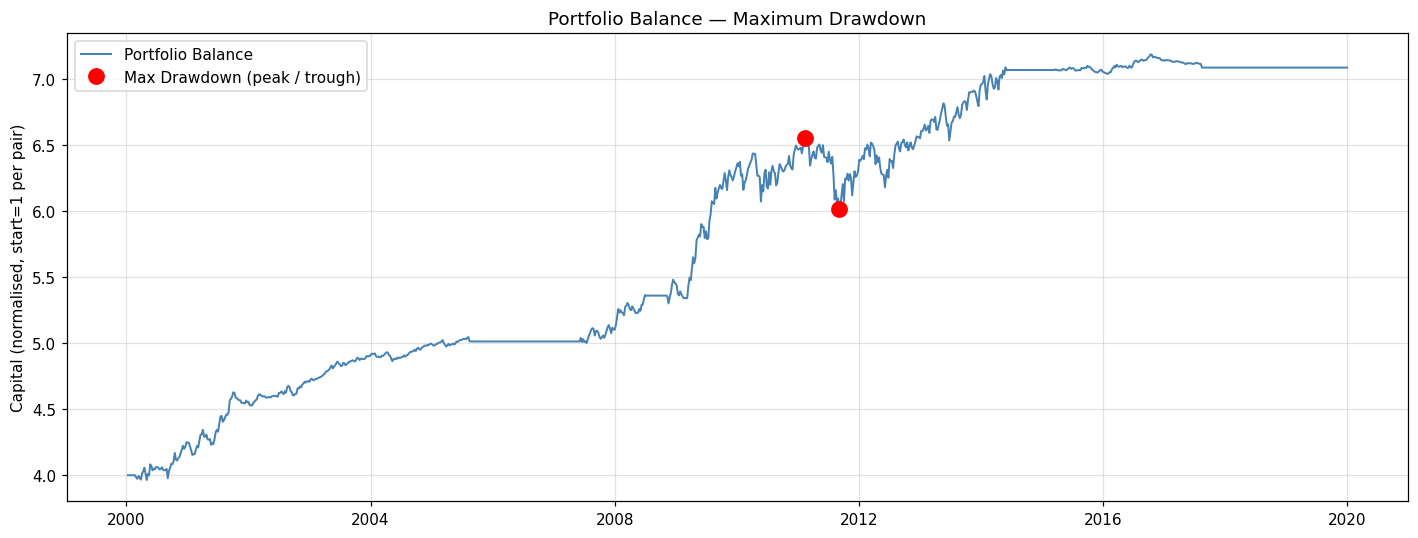

Max Drawdown       : -8.11%
Max DD Duration    : 29 weeks
Max Drawdown (portfolio): -8.11%


,Leg1,Type1,Leg2,Type2,t_stat,p_value,zero_cross,half_life_wk,hurst,pos_trades,neg_trades,sharpe_w_costs,win_rate
0,EMUSTRUU,Bond Index,LMBITR,Bond Index,-3.6061,0.0056,59,25,0.5054,5,0,1.5659,100.000000
1,LP01TREU,Bond Index,MXEU,Equity Index,-2.5761,0.0980,32,64,0.5493,3,0,0.9008,100.000000
2,LG30TRUU,Bond Index,LP01TREU,Bond Index,-2.6078,0.0914,45,82,0.5077,1,1,0.5181,50.000000
3,LMBITR,Bond Index,LUACTRUU,Bond Index,-3.1064,0.0261,58,32,0.5351,1,2,-0.1704,33.333333


In [15]:
results_train, pairs_summary_train = summarize_results(
    sharpe_train, cumret_train, perf_train, total_pairs, feature_types, N_YEARS_TRAIN
)
display(pairs_summary_train)

## 8. Test Period (Jan 2020 – Apr 2021) — Held-Out Evaluation (incl. COVID)

In [16]:
perf_test, sharpe_test, cumret_test = run_strategy(
    total_pairs, period_start=TEST_START, period_end=None, norm_params=norm_params
)

print('\n── TEST RESULTS ───────────────────────────────────────────')
for i, pair in enumerate(total_pairs):
    print(f'  {pair[0]:12s} / {pair[1]:12s}  '
          f'Sharpe={sharpe_test[i]:.3f}  CumRet={cumret_test[i]:.2f}%')


── TEST RESULTS ───────────────────────────────────────────
  LG30TRUU     / LP01TREU      Sharpe=0.000  CumRet=0.00%
  LP01TREU     / MXEU          Sharpe=0.000  CumRet=0.00%
  EMUSTRUU     / LMBITR        Sharpe=0.058  CumRet=0.18%
  LMBITR       / LUACTRUU      Sharpe=2.119  CumRet=5.29%


Average total ROI  : 1.37%
Average annual ROI : 1.03%
Pairs with positive returns: 50.0%
Portfolio Sharpe (annualised, rf=0, active wks): 0.930
Weekly return autocorrelation (lag-1): 0.014

Total trades  : 2
Winning       : 2
Losing        : 0
Total drawdown periods : 21 weeks


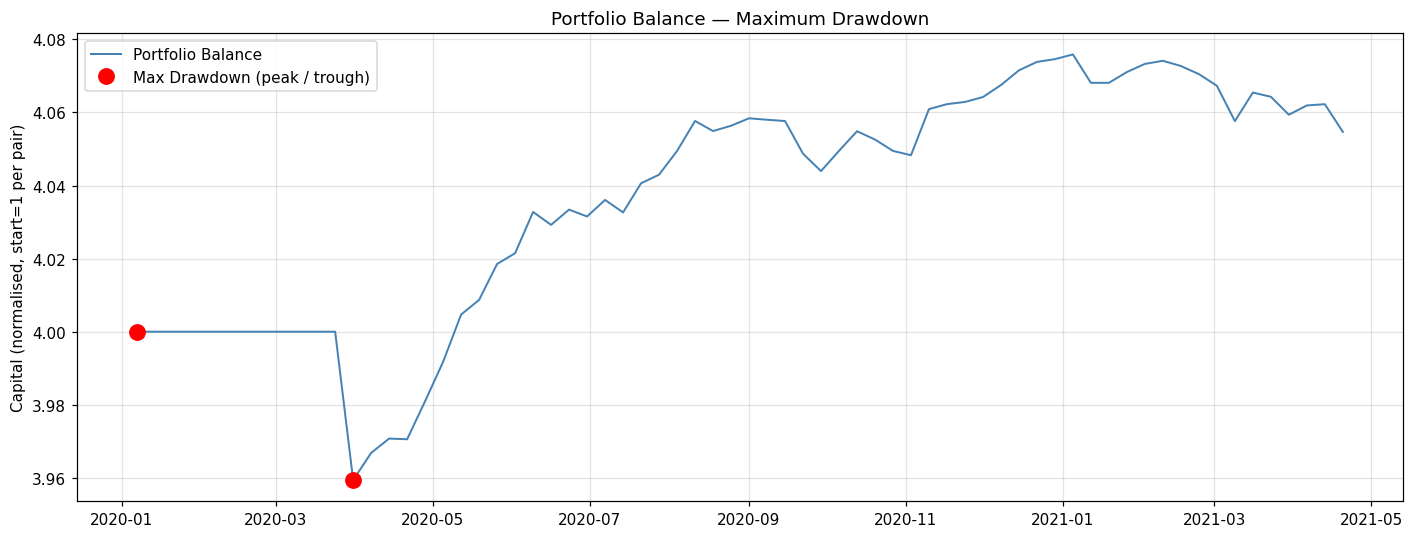

Max Drawdown       : -1.01%
Max DD Duration    : 12 weeks
Max Drawdown (portfolio): -1.01%


,Leg1,Type1,Leg2,Type2,t_stat,p_value,zero_cross,half_life_wk,hurst,pos_trades,neg_trades,sharpe_w_costs,win_rate
0,LMBITR,Bond Index,LUACTRUU,Bond Index,-3.1064,0.0261,58,32,0.5351,1,0,2.1190,100.0
1,EMUSTRUU,Bond Index,LMBITR,Bond Index,-3.6061,0.0056,59,25,0.5054,1,0,0.0575,100.0
2,LP01TREU,Bond Index,MXEU,Equity Index,-2.5761,0.0980,32,64,0.5493,0,0,0.0000,0.0
3,LG30TRUU,Bond Index,LP01TREU,Bond Index,-2.6078,0.0914,45,82,0.5077,0,0,0.0000,0.0


In [17]:
results_test, pairs_summary_test = summarize_results(
    sharpe_test, cumret_test, perf_test, total_pairs, feature_types, N_YEARS_TEST
)
display(pairs_summary_test)

## 9. Spread + Signal Plots (Full Timeline)

Each plot shows the z-score of the cointegration spread normalised with **train mean/std** across the full 2000–2021 window.  
- **Green shading** → long position active  
- **Red shading** → short position active  
- **Light red background** → risk-off period (Y=1)  
- **Dashed / dotted vertical lines** → train/val and val/test boundaries

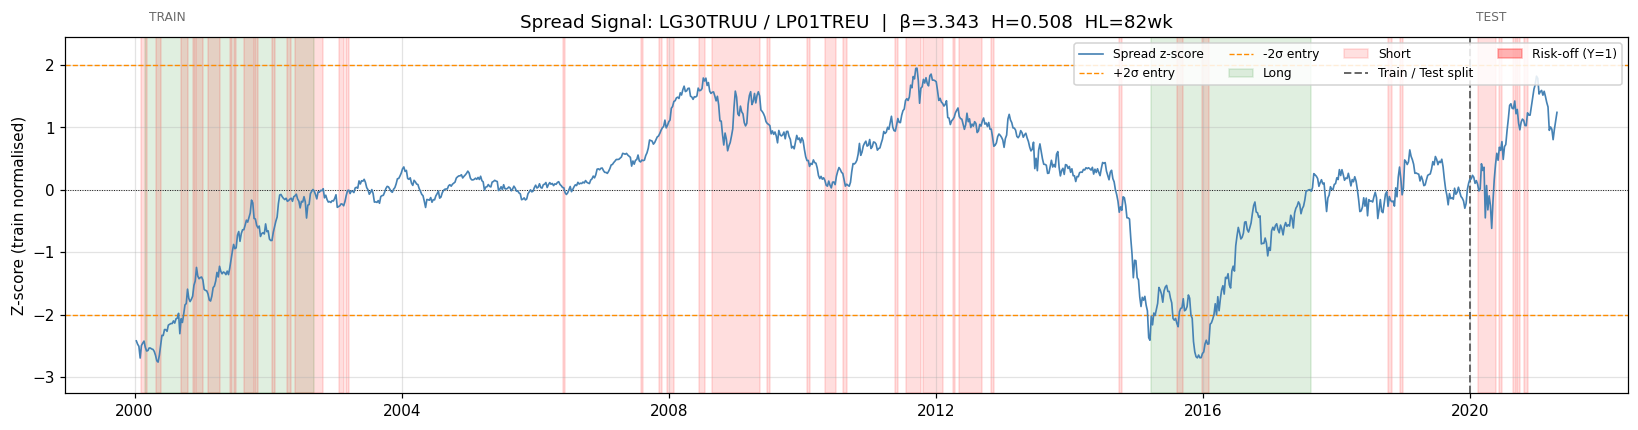

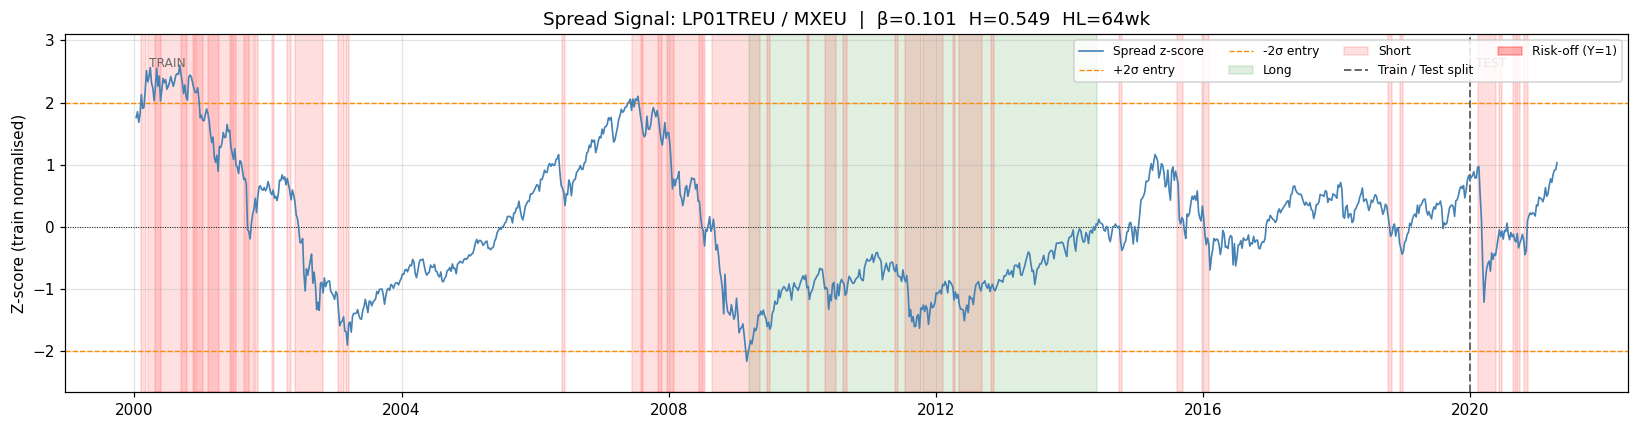

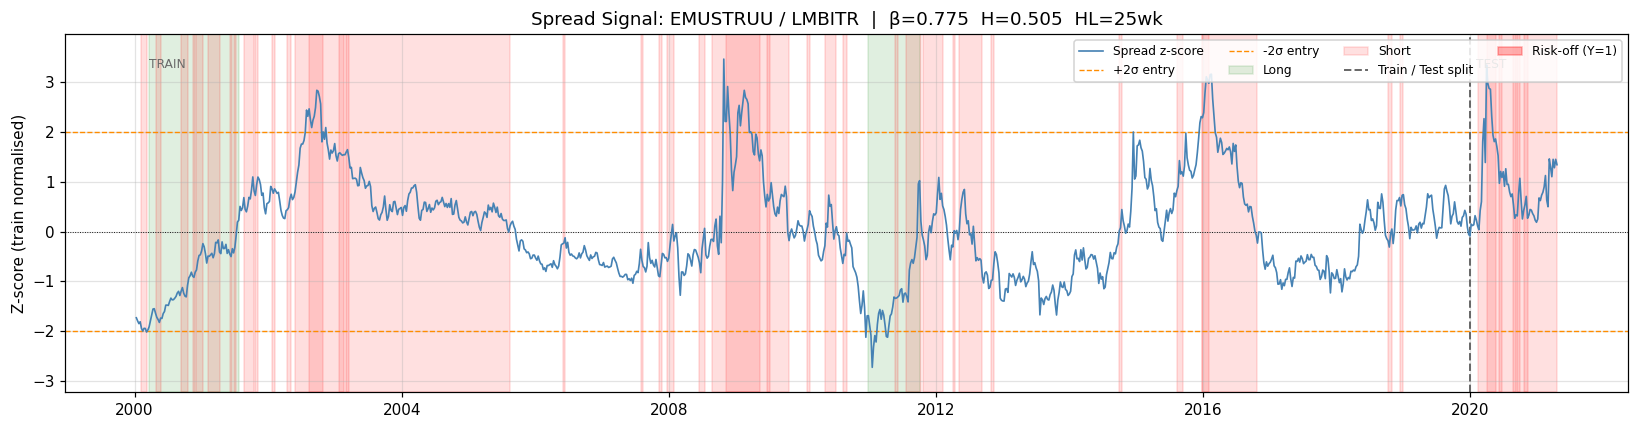

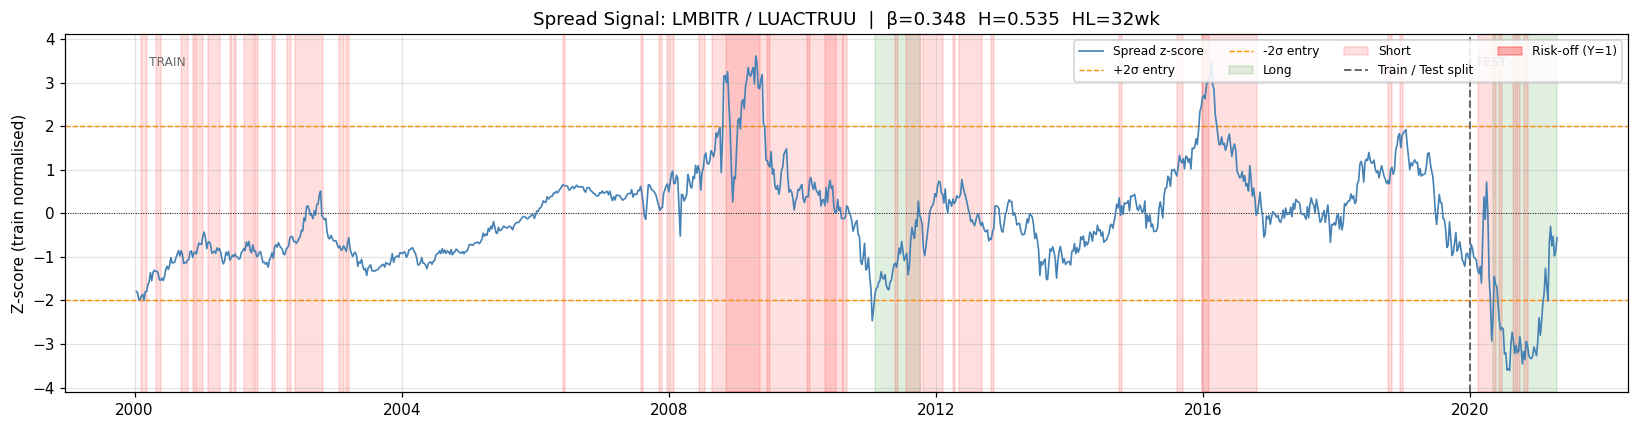

In [18]:
for i, (feat1, feat2, pair_info) in enumerate(total_pairs):
    beta = pair_info['coint_coef']
    mu   = norm_params[(feat1, feat2)]['mu']
    std  = norm_params[(feat1, feat2)]['std']

    spread_full      = pair_info['S2'] - beta * pair_info['S1']
    norm_spread_full = (spread_full - mu) / std

    positions_full = pd.concat([
        perf_train[i][1]['position_during_day'],
        perf_test[i][1]['position_during_day'],
    ])

    title_suffix = (f'  |  β={pair_info["coint_coef"]:.3f}  '
                    f'H={pair_info["hurst_exponent"]:.3f}  '
                    f'HL={pair_info["half_life"]}wk')
    plot_pair_signals(feat1, feat2, norm_spread_full, positions_full,
                      y_labels, title_suffix=title_suffix)

## 10. Equity Curves per Period

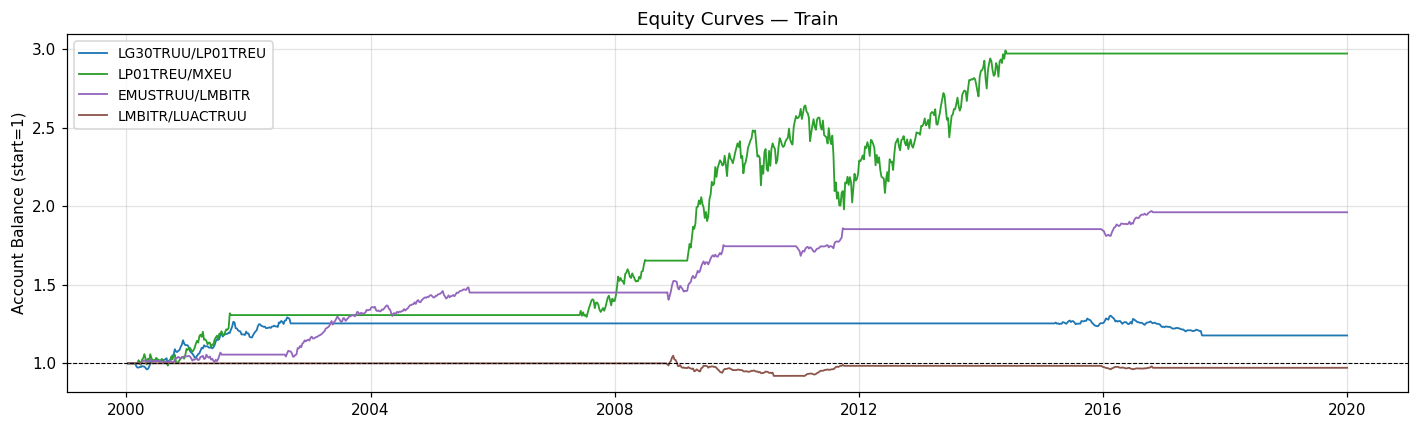

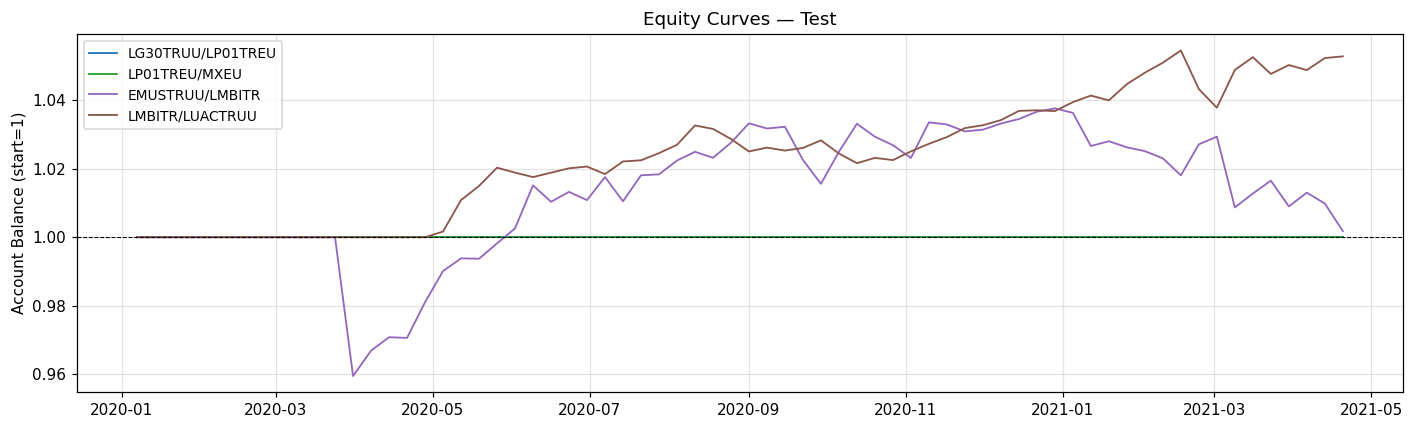

In [19]:
PERIOD_COLORS = ['#1f77b4', '#2ca02c', '#9467bd', '#8c564b']

for period_name, perf in [('Train', perf_train), ('Test', perf_test)]:
    fig, ax = plt.subplots(figsize=(13, 4))

    for i, (feat1, feat2, _) in enumerate(total_pairs):
        bal = perf[i][2]['account_balance']
        ax.plot(bal.index, bal, label=f'{feat1}/{feat2}',
                color=PERIOD_COLORS[i], linewidth=1.2)

    ax.axhline(1, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(f'Equity Curves — {period_name}')
    ax.set_ylabel('Account Balance (start=1)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 11. Performance Summary

In [20]:
summary_table = pd.DataFrame({
    'Metric': [
        'Portfolio Sharpe (in-position)',
        'Avg Total ROI (%)',
        'Avg Annual ROI (%)',
        'Max Drawdown (%)',
        'Total Trades',
        'Winning Trades',
        'Losing Trades',
        '% Positive Pairs',
    ],
    'Train': [
        round(results_train['portfolio_sharpe'],  3),
        round(results_train['avg_total_roi'],      2),
        round(results_train['avg_annual_roi'],     2),
        round(results_train['max_drawdown'],       2),
        results_train['total_trades'],
        results_train['winning_trades'],
        results_train['losing_trades'],
        round(results_train['pct_positive_pairs'], 1),
    ],
    'Test': [
        round(results_test['portfolio_sharpe'],  3),
        round(results_test['avg_total_roi'],      2),
        round(results_test['avg_annual_roi'],     2),
        round(results_test['max_drawdown'],       2),
        results_test['total_trades'],
        results_test['winning_trades'],
        results_test['losing_trades'],
        round(results_test['pct_positive_pairs'], 1),
    ],
}).set_index('Metric')

display(summary_table)

,Train,Test
Metric,,
Portfolio Sharpe (in-position),0.95,0.93
Avg Total ROI (%),77.15,1.37
Avg Annual ROI (%),2.90,1.03
Max Drawdown (%),-8.11,-1.01
Total Trades,13.00,2.00
Winning Trades,10.00,2.00
Losing Trades,3.00,0.00
% Positive Pairs,75.00,50.00
